### Statement

Solving the mixed-form Darcy problem

$$\begin{align*}
    -k\,\nabla u &= v \\
    \nabla \cdot v &= 0
\end{align*}$$

on $[-1,1]^2$ with permeability $k = 1$ inside the ball of radius $0.5$, $k = 2$ outside. Boundary conditions:

$$u = g_D \quad \text{on } \Gamma_D, \qquad v \cdot n = h \quad \text{on } \Gamma_N$$

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
sys.path.append('../..')

from src import train, utils
from torch.autograd import grad
import src.data.cube_domain as cb
import src.models.mlp_model as mm
import src.models.expert_discontinuous as ed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

L_BOUNDS = [-1.0, -1.0]
U_BOUNDS = [ 1.0,  1.0]

Using device: cuda


### Problem Data

Define the permeability $k$, the Dirichlet lifting $g_D$, the boundary shape functions $u_0$ / $v_0$, and the Neumann data $h$.

In [3]:
def k(x: torch.Tensor) -> torch.Tensor:
    """Permeability: 1 inside the ball of radius 0.5, 2 outside."""
    return torch.where(torch.norm(x, p=2, dim=1) < 0.5, 1, 2).unsqueeze(1)


def g_D(x: torch.Tensor) -> torch.Tensor:
    """Dirichlet lifting: u = 0 on left (x=-1), u = 1 on right (x=1)."""
    return 0.5 * (x[:, 0:1] + 1)


def u_0(x: torch.Tensor) -> torch.Tensor:
    """Boundary shape function for u: vanishes on Γ_D (left/right walls)."""
    return 1 - x[:, 0:1]**2


def v_0(x: torch.Tensor) -> torch.Tensor:
    """
    Boundary shape function for v: enforces v·n = h on Γ_N (top/bottom, y=±1).

    The normal on top/bottom is n = (0, ±1), so only the y-component of v
    must match the Neumann datum h there.  v_0 zeroes only the y-component
    so that the free network part vanishes at y=±1:

        v_θ = h(x) + v_0(x) ⊙ ṽ
            = [0, -1] + [1, 1-y²] ⊙ ṽ
        → at y=±1: v_y = -1 + 0 = -1  ✓, v_x = ṽ_x (free)  ✓
    """
    shape = 1 - x[:, 1:2]**2                   # (N,1), zero when y=±1
    ones  = torch.ones(x.shape[0], 1, device=x.device)
    return torch.cat([ones, shape], dim=1)       # (N,2)


def h(x: torch.Tensor) -> torch.Tensor:
    """Neumann data: v·n = -1 on top/bottom — matches FEM NEUMANN_FLUX=-1."""
    return torch.cat([torch.zeros_like(x[:, 0:1]), x[:, 1:2]], dim=1)


### Models

Two networks with **hard-enforced boundary conditions**:
- `model_u` — scalar pressure field $u$, output dim 1.  Hard constraint: $u|_{\Gamma_D} = g_D$.
- `model_v` — flux field $v$, output dim 2.  Hard constraint: $v \cdot n|_{\Gamma_N} = h$.

Both use a discontinuity-aware last activation (`disc`) to help capture the sharp permeability interface.

### Combined Expert Model

A single `DiscontinousModel` with **two sub-networks** (experts) whose raw outputs are concatenated into a `(N, 3)` tensor `[u | v_x | v_y]`. A single pair of global BC functions is then applied to the full output at once:

$$\text{output} = g_0(x) + g_1(x) \odot \tilde{\text{output}}$$

| Column | Field | $g_0$ | $g_1$ |
|--------|-------|-------|-------|
| 0 | $u$ | $g_D(x) = \tfrac{1}{2}(x+1)$ | $u_0(x) = 1-x^2$ |
| 1 | $v_x$ | $h_x(x)$ | $v_{0,x}(x) = 1$ |
| 2 | $v_y$ | $h_y(x)$ | $v_{0,y}(x) = 1-y^2$ |

`.u(x)` and `.v(x)` slice the result for convenience.


In [ ]:
def g0_combined(x: torch.Tensor) -> torch.Tensor:
    """Lifting term for the full output (N, 3): [g_D | h_x | h_y]."""
    return torch.cat([g_D(x), h(x)], dim=1)   # (N,1) | (N,2)  →  (N,3)

def g1_combined(x: torch.Tensor) -> torch.Tensor:
    """Shape function for the full output (N, 3): [u_0 | v_0_x | v_0_y]."""
    return torch.cat([u_0(x), v_0(x)], dim=1)  # (N,1) | (N,2)  →  (N,3)


combined_ctx = ed.DiscModelCtx(
    input_dim=2,
    output_dims=[1, 2],                      # expert 0 → u (1D), expert 1 → v (2D)
    hidden_layers_per_output=[
        [32, 32, 32],                        # hidden widths for u-expert
        [32, 32, 32],                        # hidden widths for v-expert
    ],
    discontinuous_per_layer=[False, True],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    normalize_inputt=True,
    hard_enforce=True,
    constraint_functions=(g0_combined, g1_combined),
)

model_combined = ed.DiscontinousModel(combined_ctx).to(device)

domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    N_int=10_000,
    N_sides=[(0, 0), (0, 0)],
    int_sampling='Latin',
    device=device,
)

domain = cb.CubeDomain(domain_ctx)

### Optimisers

In [5]:
import copy


model_init = copy.deepcopy(model_combined)

### Domain

Loaded from: darcy_solution.h5
  xy_data : (10000, 2)  on cuda:0
  v_data  : (10000,)   on cuda:0
  u range : [-0.1114, 1.0000]


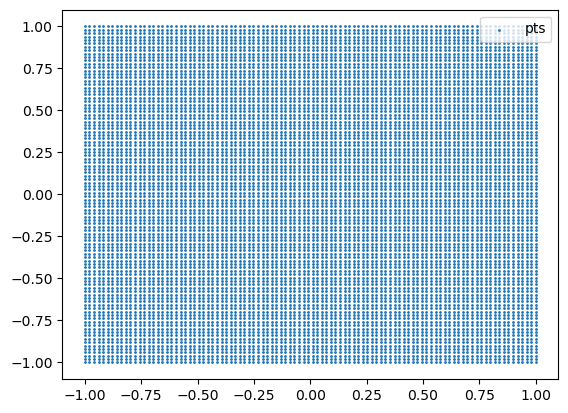

In [6]:
import h5py
import numpy as np

HDF5_PATH = "darcy_solution.h5"

with h5py.File(HDF5_PATH, "r") as f:
    xy_np = f["samples/xy"][:]          # (N, 2)  query point coordinates
    u_np  = f["samples/u_interp"][:]    # (N,)    interpolated pressure values

# Convert to tensors and move to device (no requires_grad here;
# loss_u_model detaches, loss_v_model re-enables it explicitly)
xy_data = torch.tensor(xy_np, dtype=torch.float32).to(device)
v_data  = torch.tensor(u_np,  dtype=torch.float32).to(device)

print(f"Loaded from: {HDF5_PATH}")
print(f"  xy_data : {tuple(xy_data.shape)}  on {xy_data.device}")
print(f"  v_data  : {tuple(v_data.shape)}   on {v_data.device}")
print(f"  u range : [{v_data.min():.4f}, {v_data.max():.4f}]")

utils.plot_points({"pts": xy_data})


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# PHASE 1 — Loss functions: fit to FEM reference data
# ───────────────────────────────────────────────────────────────────────────
# Both functions receive model_combined as `model`.
# ═══════════════════════════════════════════════════════════════════════════


def loss_u_data(model: torch.nn.Module, domain: cb.CubeDomain):
    inp_data = xy_data.detach()
    u_data_out = model(inp_data)[:, 0:1]
    loss_data  = torch.mean((u_data_out - v_data.unsqueeze(1))**2)

    return [loss_data]


def loss_v_data(model: torch.nn.Module, domain: cb.CubeDomain):
    inp = xy_data.detach().requires_grad_(True)

    # freeze u-expert so its parameters receive no gradient
    for p in model.experts[0].parameters():
        p.requires_grad_(False)

    u_out  = model(inp)[:, 0]                          # (N,)
    u_grad = grad(u_out, inp,
                  grad_outputs=torch.ones_like(u_out),
                  create_graph=True)[0]                # (N, 2)  ∇u w.r.t. input
    v_out  = model(inp)[:, 1:]                         # (N, 2)

    for p in model.experts[0].parameters():
        p.requires_grad_(True)

    res = v_out + k(inp).detach() * u_grad
    return [torch.mean(res**2)]


# ═══════════════════════════════════════════════════════════════════════════
# PHASE 2 — Joint PDE loss: trains u- and v-experts together
# ───────────────────────────────────────────────────────────────────────────
#  All parameters of model_combined are active simultaneously.
#  Three residuals are combined into one scalar:
#    L_c  = ||v + k ∇u||²           constitutive (couples both experts)
#    L_d  = ||∂v_x/∂x + ∂v_y/∂y||² divergence-free constraint on v
# ═══════════════════════════════════════════════════════════════════════════

LAMBDA_PDE = 1.0   # weight on constitutive vs. divergence term

def loss_pde(model: torch.nn.Module, domain: cb.CubeDomain):
    """
    Joint PDE residual loss — both experts updated together.

    Minimises:
        LAMBDA_PDE * ||v + k ∇u||²  +  ||∇·v||²

    over all parameters of `model`.  No freezing: gradients flow through
    both the u-expert (via ∇u) and the v-expert (via v_out) simultaneously.
    """
    pde_in = domain.interior.detach().requires_grad_(True)

    out    = model(pde_in)                             # (N, 3)
    u_out  = out[:, 0]                                 # (N,)
    v_out  = out[:, 1:]                                # (N, 2)

    # ── ∇u (differentiate u w.r.t. input; k detached — torch.where has 0 grad)
    u_grad = grad(u_out, pde_in,
                  grad_outputs=torch.ones_like(u_out),
                  create_graph=True)[0]                # (N, 2)

    # ── constitutive residual: v + k ∇u = 0
    res_c = v_out + k(pde_in).detach() * u_grad        # (N, 2)

    # ── divergence residual: ∂v_x/∂x + ∂v_y/∂y = 0
    v_x, v_y = v_out[:, 0], v_out[:, 1]
    dv_x = grad(v_x, pde_in,
                grad_outputs=torch.ones_like(v_x),
                create_graph=True)[0][:, 0]            # (N,)
    dv_y = grad(v_y, pde_in,
                grad_outputs=torch.ones_like(v_y),
                create_graph=True)[0][:, 1]            # (N,)
    res_d = dv_x + dv_y                                # (N,)

    return [100*torch.mean(res_c**2), torch.mean(res_d**2)]


In [9]:
# ── Phase 1: train against FEM reference ────────────────────────────────────
print("=" * 60)
print("PHASE 1: fitting to FEM reference solution")
print("=" * 60)

# Rebuild fresh optimisers/schedulers so Phase 1 starts from a clean state
optim_combined = torch.optim.Adam(model_combined.parameters(), lr=5e-4)
scheduler_combined = ReduceLROnPlateau(optim_combined, factor=0.5, patience=200)

train_ctx_u_data = train.TrainingContext(
    model=model_combined,
    domain=domain,
    optimizer=optim_combined,
    loss_fn=loss_u_data,
    epochs=7_000,
    monitor_gradient=True,
    monitor_lr=True,
    scheduler=scheduler_combined
)

train_ctx_v_data = train.TrainingContext(
    model=model_combined,
    domain=domain,
    optimizer=torch.optim.Adam(model_combined.parameters(), lr=1e-4),
    loss_fn=loss_v_data,
    epochs=20_000,
    monitor_gradient=True,
    monitor_lr=True,
)

print("\n[1/2] Fitting model_u to FEM pressure values …")
u_loss_phase1, _ = train.train_switch_to_lbfgs(train_ctx_u_data, lbfgs_lr=0.1)

print("\n[2/2] Fitting model_v to FEM pressure values …")
u_loss_phase2, _ = train.train_switch_to_lbfgs(train_ctx_v_data, lbfgs_lr=0.1)

print("\nPhase 1 complete.")

model_fem = copy.deepcopy(model_combined)

PHASE 1: fitting to FEM reference solution

[1/2] Fitting model_u to FEM pressure values …
Loss at epoch 1 is: 0.00019550963770598173. Total gradient norm: 0.00018994916606128307 Current learing rate: 0.0005 


Loss at epoch 100 is: 0.00018581637414172292. Total gradient norm: 0.001054756105738562 Current learing rate: 0.0005 
Loss at epoch 200 is: 0.00017549065523780882. Total gradient norm: 0.00020155108746746113 Current learing rate: 0.0005 
Loss at epoch 300 is: 0.00016518289339728653. Total gradient norm: 0.00030071824383999426 Current learing rate: 0.0005 
Loss at epoch 400 is: 0.00015479669673368335. Total gradient norm: 0.0006984425296120637 Current learing rate: 0.0005 
Loss at epoch 500 is: 0.00014841972733847797. Total gradient norm: 0.009428999212027339 Current learing rate: 0.0005 
Loss at epoch 600 is: 0.00013060819765087217. Total gradient norm: 0.00023368628762868382 Current learing rate: 0.0005 
Loss at epoch 700 is: 0.00011851305316668004. Total gradient norm: 0.005465562525310706 Current learing rate: 0.0005 
Loss at epoch 800 is: 0.00010295720858266577. Total gradient norm: 0.0007070927167424207 Current learing rate: 0.0005 
Loss at epoch 900 is: 9.335802315035835e-05. Tot

In [ ]:
train_ctx_pde = train.TrainingContext(
    model=model_combined,
    domain=domain,
    optimizer=torch.optim.Adam(model_combined.parameters(), lr=1e-4),
    loss_fn=loss_pde,
    epochs=20_000,
    monitor_gradient=True,
    monitor_lr=True,
)

pde_loss, pde_loss_comp = train.train_switch_to_lbfgs(train_ctx_pde, lbfgs_lr=0.1)

Loss at epoch 1 is: 5.57074499130249. Total gradient norm: inf Current learing rate: 0.0001 
Loss at epoch 100 is: 1.4960163831710815. Total gradient norm: 4.924859824450221 Current learing rate: 0.0001 


KeyboardInterrupt: 

/home/berva/miniconda3/envs/torch/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/libtorch_1745854776362/work/aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


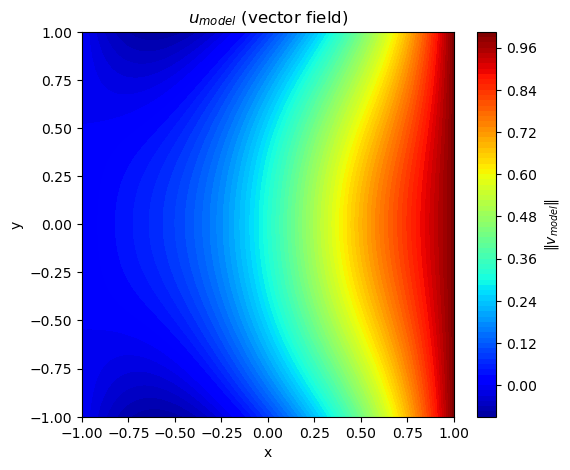

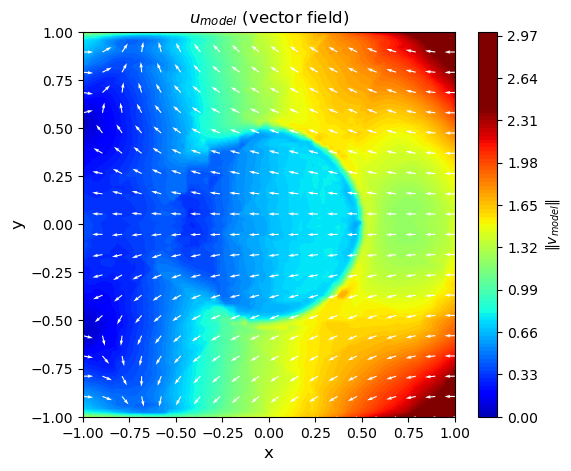

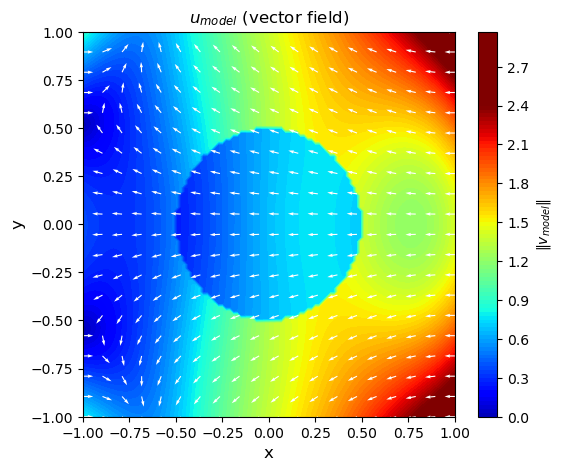

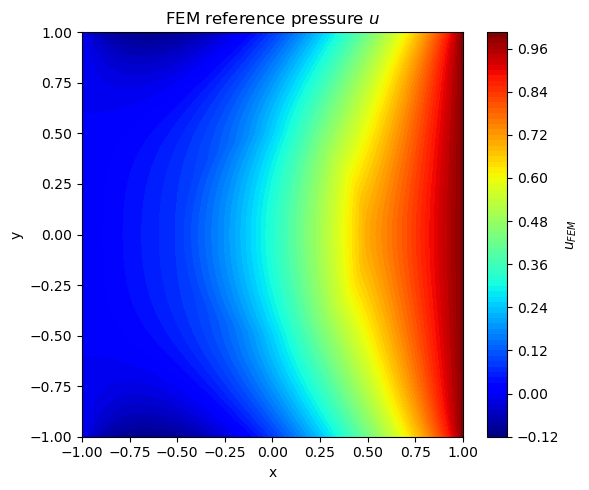

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from src.utils import PlotContext, plot_vector_field_2d, plot_function_on_2d_cube


# --- vector field: model_v ---
vec_ctx = PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    function_names=[r'$\|v_{model}\|$'],
    titles=[r'$u_{model}$ (vector field)'],
    N=100,
    colour_map='jet',
    device=str(device),
    patches=[],
    figsize=(6, 5),
    vmin=-0.12,
    vmax=1.0,
)


def heat_flow(x):
    x.requires_grad_(True)
    u = model_combined(x)[:, 0]
    
    return - k(x) * grad(u, x, torch.ones_like(u))[0]


with torch.no_grad():
    plot_function_on_2d_cube([lambda x: model_combined(x)[:, 0]], vec_ctx)
    vec_ctx.vmax=2.4
    plot_vector_field_2d([lambda x: model_combined(x)[:, 1:3]], vec_ctx, N=100, n_heigth=20, n_width=20)

plot_vector_field_2d([heat_flow], vec_ctx, N=100, n_heigth=20, n_width=20)

# --- scalar heatmap: v_data (FEM reference pressure) ---
# xy_data is a (10000,2) regular 100x100 grid; v_data is the matching (10000,) scalar
xy_np_plot = xy_data.detach().cpu().numpy()
v_np = v_data.cpu().numpy()

# determine grid resolution from xy_data
xs = np.unique(xy_np_plot[:, 0])
ys = np.unique(xy_np_plot[:, 1])
nx_g, ny_g = len(xs), len(ys)

X_grid = xy_np_plot[:, 0].reshape(nx_g, ny_g)
Y_grid = xy_np_plot[:, 1].reshape(nx_g, ny_g)
V_grid = v_np.reshape(nx_g, ny_g)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
contour = ax.contourf(X_grid, Y_grid, V_grid, levels=100, cmap='jet')
fig.colorbar(contour, ax=ax, label=r'$u_{FEM}$')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('FEM reference pressure $u$')
plt.tight_layout()

plt.show()


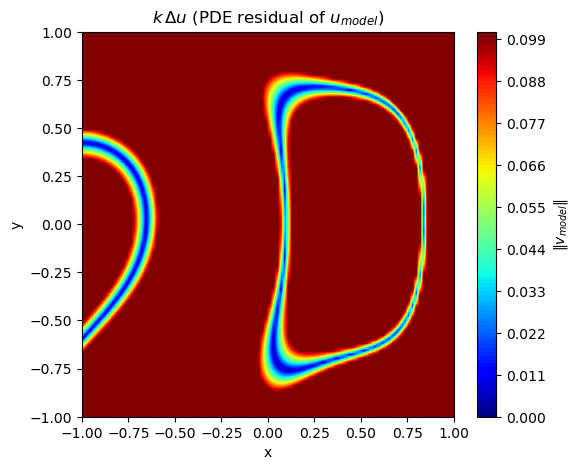

In [11]:
def pde_residuum(pde_input: torch.Tensor, model: torch.nn.Module) -> torch.Tensor:
    """
    Compute the strong-form residual ∇·(k ∇u) at interior points.

    For piecewise-constant k, torch.where has zero gradient everywhere, so
    differentiating k(x)*grad_u through autograd silently drops the ∇k·∇u
    term (a Dirac delta on the interface).  To avoid this, we differentiate
    only u and multiply by k *after* both derivative passes:

        ∇·(k ∇u) = k Δu + ∇k·∇u
                  = k (u_xx + u_yy)   [∇k = 0 a.e. for piecewise-const k]

    This is correct away from the interface.
    """
    x = pde_input.requires_grad_(True)
    u = model(x)[:, 0]                                                   # (N, 1)

    # First derivatives — do NOT multiply by k yet
    u_grad = grad(u, x, grad_outputs=torch.ones_like(u),
                  create_graph=True)[0]                             # (N, 2)
    u_x, u_y = u_grad[:, 0], u_grad[:, 1]

    # Second derivatives
    u_xx = grad(u_x, x, grad_outputs=torch.ones_like(u_x),
                create_graph=True)[0][:, 0]
    u_yy = grad(u_y, x, grad_outputs=torch.ones_like(u_y),
                create_graph=True)[0][:, 1]

    return ((u_xx + u_yy))

vec_ctx.vmin=0
vec_ctx.vmax = 0.1
vec_ctx.titles = [r"$k\,\Delta u$ (PDE residual of $u_{model}$)"]
utils.plot_function_on_2d_cube(
    [lambda x: torch.clamp(torch.abs(pde_residuum(x, model_combined)), 0.0, 0.1)], vec_ctx)


In [ ]:
def weight_distance(model_before_sd, model_after_sd):
    """state_dict → dict of per-layer and total distances."""
    model_before_sd_params = model_before_sd.named_parameters()
    model_after_sd_params = model_after_sd.named_parameters()
    diffs = {}
    diffs_rel = {}
    for p_bef, p_aft in zip(model_before_sd_params, model_after_sd_params):
        diffs_rel[p_bef[0]] = torch.div(torch.sqrt((p_bef[1] - p_aft[1])**2),
                                        torch.abs(p_bef[1]))
        diffs[p_bef[0]] = torch.sqrt((p_bef[1] - p_aft[1])**2)
    return diffs, diffs_rel

model_fem = copy.deepcopy(model_combined)

abs_diffs, rel_diffs = weight_distance(model_init, model_fem)

for key in abs_diffs.keys():
    print(f"Parameter/layer {key}:\n")
    print(f"maximal relative change: {torch.max(rel_diffs[key])}.")
    print(f"maximal absolute change: {torch.max(abs_diffs[key])}.\n")
    if key == "experts.1.2.jump_centre":
        print(abs_diffs[key])
    

Parameter/layer experts.0.1.weight:

maximal relative change: 30.70563316345215.
maximal absolute change: 1.334968090057373.

Parameter/layer experts.0.1.bias:

maximal relative change: 1.5163097381591797.
maximal absolute change: 0.31057798862457275.

Parameter/layer experts.0.3.weight:

maximal relative change: 278.83404541015625.
maximal absolute change: 1.2294881343841553.

Parameter/layer experts.0.3.bias:

maximal relative change: 51.52168273925781.
maximal absolute change: 0.16213136911392212.

Parameter/layer experts.0.5.weight:

maximal relative change: 927.9259033203125.
maximal absolute change: 1.1853820085525513.

Parameter/layer experts.0.5.bias:

maximal relative change: 10.981329917907715.
maximal absolute change: 0.053103238344192505.

Parameter/layer experts.0.7.weight:

maximal relative change: 614.4318237304688.
maximal absolute change: 0.5303440093994141.

Parameter/layer experts.0.7.bias:

maximal relative change: 17.123083114624023.
maximal absolute change: 0.0386